# **Advanced Exploratory Data Analysis of Titanic Dataset**

![Titanic](https://upload.wikimedia.org/wikipedia/commons/f/fd/RMS_Titanic_3.jpg)


---

## 📌 Overview
The Titanic dataset contains passenger details such as age, gender, class, and fare, used to analyze survival patterns.  
In this analysis, we clean missing data, detect outliers, and use visualizations to uncover key insights influencing survival.

---

## 🎯 Objective
*Clean & Visualize Real-World Data*
- Handle missing values  
- Detect outliers  
- Create visualizations  
- Identify key survival factors  

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# **Load Dataset**

In [16]:
from google.colab import files
uploaded = files.upload()
train = pd.read_csv('train.csv')
train.head()

Saving train.csv to train (2).csv


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Dataset Overview

In [17]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Interpretation

The dataset contains **891 entries and 12 columns**, including both numerical and categorical features.  
Key variables such as *Age*, *Cabin*, and *Embarked* have missing values, with **Cabin missing the most data**, making it less reliable for analysis.

There are **5 numerical columns** (e.g., Age, Fare) and **5 categorical columns** (e.g., Sex, Embarked), indicating a mix of data types.  

---
*Overall, the dataset is well-structured but requires **data cleaning**, especially handling missing values before performing further analysis or modeling.*

---

# **Data Cleaning**
## Missing Values

In [18]:
train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## Handling Missing Values

- **Age** → Filled with median (robust to outliers)
- **Embarked** → Filled with mode (categorical)
- **Cabin** → Dropped (too many missing values)


In [19]:
train['Age'] = train['Age'].fillna(train['Age'].median())
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])
train.drop(columns=['Cabin'], inplace=True)

train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


### Interpretation

The dataset exhibited missing values primarily in Age, Cabin, and Embarked, with Cabin having the largest proportion of null entries.  
Due to excessive missing data, the Cabin column was dropped as it could introduce noise and reduce analytical reliability.

Age values were imputed using the median to preserve the distribution and reduce the impact of outliers, while Embarked values were filled using the most frequent category.  
These preprocessing decisions ensure that the dataset remains unbiased and statistically consistent.

After cleaning, the dataset is complete with **zero missing values**, providing a solid foundation for visualization and machine learning tasks.

---

*This step improves data quality and ensures that further analysis is based on complete and reliable information.*

---

# **Exploratory Data Analysis**
## Outlier Detection of Fare

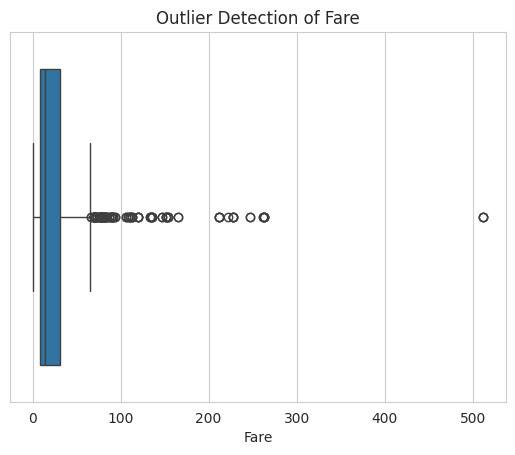

In [25]:
plt.figure()
sns.boxplot(x=train['Fare'])
plt.title('Outlier Detection of Fare')
plt.show()

### Interpretation

The boxplot of the Fare variable shows a **highly right-skewed distribution**, used for Outlier Detection where most passengers paid relatively low fares, concentrated near the lower range.

However, there are **many extreme outliers on the higher end**, indicating that a small number of passengers paid significantly higher fares compared to the majority. These outliers likely correspond to passengers in higher classes (e.g., first class) or those with premium accommodations.

The presence of these outliers suggests a wide variation in ticket pricing. While they are valid observations and should not be removed arbitrarily, they may influence statistical measures like the mean.

---

*Overall, the Fare feature contains important information and reflects socioeconomic differences among passengers, which could be a key factor in survival analysis.*

## Histogram of Age Distribution

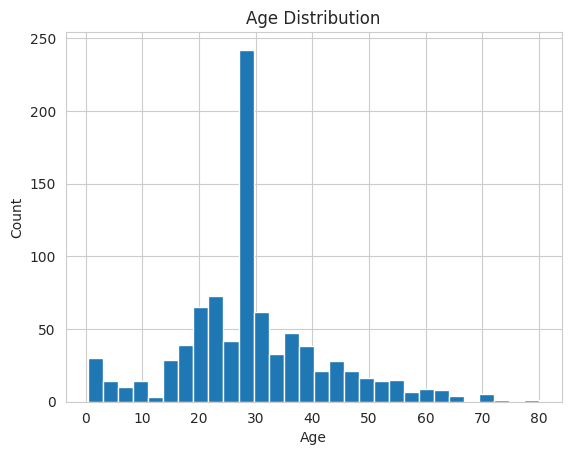

In [21]:
plt.figure()
plt.hist(train['Age'], bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

### Interpretation

The histogram shows that the Age variable follows a **slightly right-skewed distribution**, with most passengers concentrated in the age range of approximately **20 to 35 years**.

There is a noticeable peak around the late 20s, indicating that a large proportion of passengers were young adults.  
The distribution gradually decreases as age increases, with fewer passengers in older age groups.

Additionally, there are a small number of **very young passengers (children)** and **elderly individuals**, indicating a diverse age range onboard.

---

*Overall, the Age feature appears to be reasonably distributed, and the median imputation used during data cleaning has preserved the general shape of the distribution without introducing major bias.*

---

## Bar Chart of Survival Rate by Gender

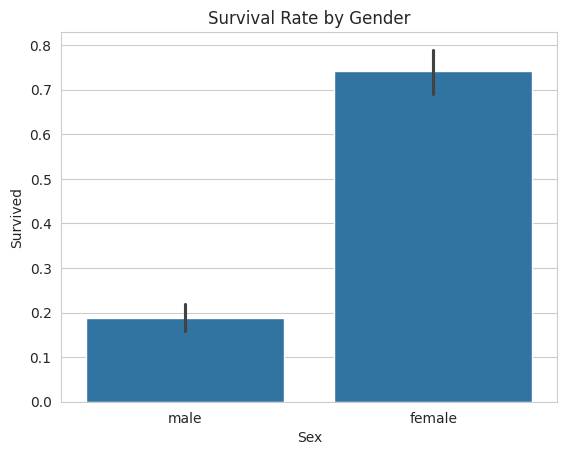

In [23]:
plt.figure()
sns.barplot(x='Sex', y='Survived', data=train)
plt.title('Survival Rate by Gender')
plt.show()

### Interpretation

The bar chart clearly shows a significant difference in survival rates between male and female passengers.

Female passengers have a much higher survival rate (around 74%), whereas male passengers have a significantly lower survival rate (around 19%).  
This indicates that gender played a crucial role in survival outcomes.

The result reflects the historical evacuation protocol of **“women and children first”**, which prioritized female passengers during rescue operations.

---

*Overall, Sex is one of the most important features influencing survival and will likely be a strong predictor in any predictive model.*

---

## Correlation Heatmap

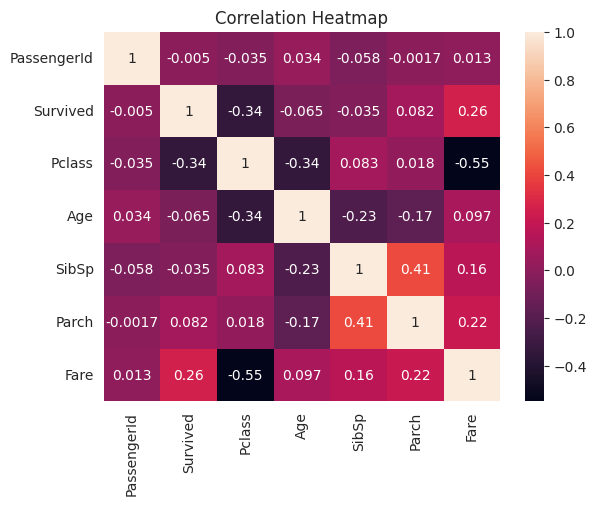

In [24]:
plt.figure()
corr = train.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title('Correlation Heatmap')
plt.show()

### Interpretation

The correlation heatmap shows the relationships between numerical features in the dataset.

The strongest correlation with survival is observed for:
- **Fare (≈ +0.26)** → Positive correlation, indicating that passengers who paid higher fares had a higher chance of survival.
- **Pclass (≈ -0.34)** → Negative correlation, meaning passengers in lower classes (higher Pclass value) had lower survival rates.

This suggests that **socioeconomic status played a significant role in survival**, as higher-class passengers (low Pclass, high Fare) were more likely to survive.

Other features such as Age, SibSp, and Parch show **weak correlations** with survival, indicating they have less direct impact individually.

Additionally:
- **Fare and Pclass (-0.55)** show a strong negative correlation, confirming that higher-class passengers paid higher fares.
- **SibSp and Parch (+0.41)** are moderately correlated, as both relate to family connections onboard.

---

*Overall, Pclass and Fare are key features influencing survival, while other variables may contribute in combination rather than individually.*

---

## Key Insights

- **Gender had the biggest impact on survival**  
  Females were much more likely to survive than males.

- **Passenger class mattered**  
  People in higher classes (1st class) had better chances of survival than those in lower classes (3rd class).

- **Fare also played a role**  
  Passengers who paid higher ticket prices were more likely to survive.

- **Age had less impact**  
  Most passengers were young adults, and age did not strongly affect survival.

- **Family presence had a small effect**  
  Traveling with family slightly influenced survival, but not as much as gender or class.

---

## Conclusion

- Cleaning the data helped remove errors and made the analysis more accurate.
- Visualizations made it easier to understand patterns in the data.
- The most important factor for survival was **gender**, followed by **passenger class and fare**.
- These insights show how analyzing data step-by-step helps us understand real-world events better.

---

***Overall, this analysis shows that good data cleaning and visualization are essential before building any machine learning model.***

---